In [1]:
import os

image_paths = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

# First 5 image paths
for p in image_paths[:5]:
    print(p)

Total images found: 12218
/kaggle/input/datasets/kriiiiimsh/medical-images/mri/no/34 no.jpg
/kaggle/input/datasets/kriiiiimsh/medical-images/mri/no/N20.JPG
/kaggle/input/datasets/kriiiiimsh/medical-images/mri/no/N1.JPG
/kaggle/input/datasets/kriiiiimsh/medical-images/mri/no/49 no.jpg
/kaggle/input/datasets/kriiiiimsh/medical-images/mri/no/N15.jpg


Shape: (198, 150)
Min pixel: 0
Max pixel: 255


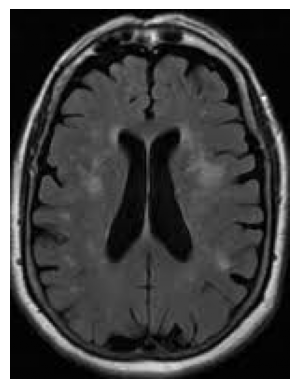

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[0], 0)

print("Shape:", img.shape)
print("Min pixel:", img.min())
print("Max pixel:", img.max())

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [3]:
sizes = {}

for path in image_paths[:100]:
    img = cv2.imread(path, 0)

    shape = img.shape

    if shape in sizes:
        sizes[shape] += 1
    else:
        sizes[shape] = 1

print(sizes)

{(198, 150): 1, (262, 227): 1, (338, 276): 1, (225, 225): 16, (454, 442): 1, (252, 200): 2, (236, 214): 1, (442, 442): 4, (264, 210): 1, (250, 201): 2, (192, 192): 1, (231, 218): 2, (449, 359): 1, (234, 215): 1, (530, 380): 1, (168, 300): 3, (280, 420): 1, (630, 630): 6, (680, 680): 1, (326, 276): 1, (537, 472): 1, (217, 232): 3, (259, 194): 1, (614, 630): 1, (400, 393): 2, (725, 728): 1, (221, 228): 2, (282, 230): 1, (214, 235): 1, (442, 400): 1, (474, 356): 1, (243, 207): 1, (200, 300): 1, (442, 441): 1, (251, 201): 3, (444, 468): 1, (750, 750): 1, (417, 428): 1, (201, 173): 2, (393, 350): 1, (197, 177): 1, (361, 642): 1, (1080, 1920): 1, (275, 220): 2, (540, 504): 1, (200, 200): 1, (183, 275): 1, (248, 208): 1, (244, 206): 1, (340, 339): 1, (301, 275): 1, (512, 512): 1, (242, 208): 2, (442, 409): 1, (1024, 1024): 1, (222, 227): 1, (194, 259): 1, (664, 550): 1, (238, 212): 1, (257, 196): 1, (213, 236): 1, (298, 260): 1, (342, 273): 1}


In [4]:
selected = []
selected2 = []

for path in image_paths:
    img = cv2.imread(path, 0)
    h, w = img.shape

    if min(h, w) >= 400 and max(h,w) <= 700:
        selected.append(path)

    if min(h, w) >= 300 and max(h,w) <= 700:
        selected2.append(path)

print("Selected images:", len(selected))
print("Selected images:", len(selected2))

Selected images: 110
Selected images: 230


In [5]:
selected = selected2

In [6]:
import random

random.seed(42)

selected_paths = random.sample(selected, 200)

print(len(selected_paths))

200


In [7]:
for path in selected_paths[:5]:
    img = cv2.imread(path, 0)
    print(img.shape)

(336, 300)
(630, 630)
(680, 680)
(375, 668)
(520, 433)


In [8]:
processed_images = []

for path in selected_paths:
    img = cv2.imread(path, 0)
    img = cv2.resize(img, (512, 512))
    processed_images.append(img)

print(processed_images[0].shape)

(512, 512)


In [9]:
def med_predict(a, b, c):

    if c >= max(a, b):
        return min(a, b)

    elif c <= min(a, b):
        return max(a, b)

    else:
        return a + b - c

In [10]:
print(
    med_predict(
        93,
        102,
        101
    )
)

94


Shape: (512, 512)
Data type: uint8


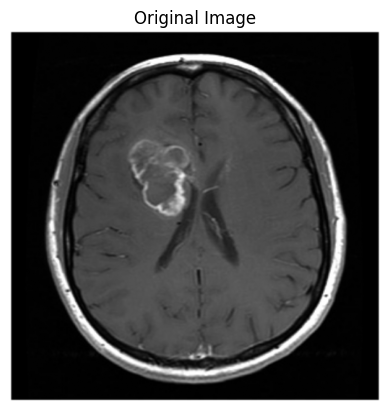

In [11]:
img = processed_images[0]

print("Shape:", img.shape)
print("Data type:", img.dtype)

import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [12]:
img = processed_images[0]

# Current pixel
i, j = 100, 100

a = int(img[i, j-1])      # Left
b = int(img[i-1, j])      # Top
c = int(img[i-1, j-1])    # Top-left

prediction = med_predict(a, b, c)
actual = int(img[i, j])

error = actual - prediction

print("Left (a):", a)
print("Top (b):", b)
print("Top-left (c):", c)
print("Prediction:", prediction)
print("Actual:", actual)
print("Prediction Error:", error)

Left (a): 1
Top (b): 1
Top-left (c): 1
Prediction: 1
Actual: 2
Prediction Error: 1


### Prediction Error Map -- Eq (1)
The original `prediction_error_map` set `pe[0,0] = img[0,0]` (the raw pixel value). The paper's Eq (1) requires **p(1,1) = 0**; the first pixel value `x(1,1)` is carried as separate side information (stored explicitly in the encrypted image, see *Encrypted Image Construction* below) rather than folded into the prediction-error map. 

In [13]:
import numpy as np

def prediction_error_map(img):
    h, w = img.shape

    pe = np.zeros((h, w), dtype=np.int32)

    for i in range(h):
        for j in range(w):

            # First pixel: p(1,1) = 0  -- Eq (1). x(1,1) is stored
            # separately as side information, not folded in here.
            if i == 0 and j == 0:
                pe[i, j] = 0

            # First row
            elif i == 0:
                pe[i, j] = int(img[i, j]) - int(img[i, j-1])

            # First column
            elif j == 0:
                pe[i, j] = int(img[i, j]) - int(img[i-1, j])

            # Remaining pixels: MED prediction
            else:
                a = int(img[i, j-1])
                b = int(img[i-1, j])
                c = int(img[i-1, j-1])

                pred = med_predict(a, b, c)

                pe[i, j] = int(img[i, j]) - pred

    return pe


def inverse_prediction(pe, x11):
    """Exact inverse of prediction_error_map, used for perfect image
    recovery: first pixel is x11 (stored separately), everything else
    is reconstructed by inverting Eq (1) left-to-right, top-to-bottom."""
    h, w = pe.shape
    X = np.zeros((h, w), dtype=np.int32)
    X[0, 0] = x11
    for i in range(h):
        for j in range(w):
            if i == 0 and j == 0:
                continue
            elif i == 0:
                X[i, j] = pe[i, j] + X[i, j-1]
            elif j == 0:
                X[i, j] = pe[i, j] + X[i-1, j]
            else:
                a = int(X[i, j-1]); b = int(X[i-1, j]); c = int(X[i-1, j-1])
                X[i, j] = pe[i, j] + med_predict(a, b, c)
    return X.astype(np.uint8)

In [14]:
pe = prediction_error_map(processed_images[0])

print("Shape:", pe.shape)
print("Minimum Error:", pe.min())
print("Maximum Error:", pe.max())

Shape: (512, 512)
Minimum Error: -118
Maximum Error: 71


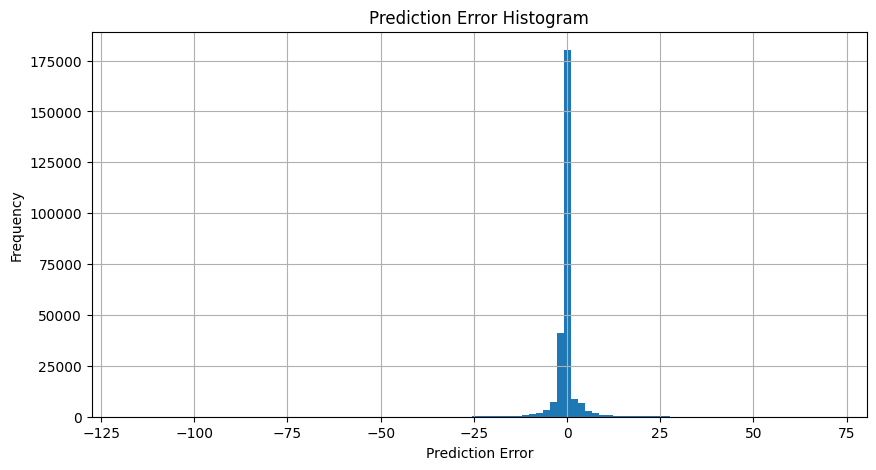

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(pe.flatten(), bins=100)
plt.title("Prediction Error Histogram")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Hybrid Tree Coding (HTC): Canonical Huffman Tree Construction & Adjustment



```
MED Prediction -> Prediction Error Map -> Hybrid Tree Coding (HTC)
  [Canonical Huffman Tree + Adjustment -> HC + LLC -> Adaptive Selection]
  -> Location Map M -> Arithmetic Coding of M
  -> Label Sequence V -> Arithmetic Coding of V
  -> Coding Stream C (Eq 6)
  -> Count-Encryption (CE, SHA-512, Eq 7/9) -> Coding Stream C'
  -> Encrypted Image Construction (Eq 8/10) -> Y
  -> Reserved Room Before Encryption (already reserved by construction of Y)
  -> Bit Replacement Data Hiding -> Marked Encrypted Image Z
  -> Data Extraction (separable, no key needed)
  -> Count-Decryption (Eq 12) -> HTC Decoding -> Inverse Prediction
  -> Perfect Image Recovery
```

This first block builds the **canonical Huffman tree** `Tc` from the prediction-error histogram, then applies the **tree adjustment** described in Section IV-A-2 (common-parent optimisation using adjacent error pairs `Ppe`/`Poe`, the label array `S`, and the leftmost-free-slot swap rule) to produce the adjusted tree `T` used by both HC and LLC.

In [16]:
import heapq
from collections import Counter, defaultdict

def compute_huffman_lengths(freq: dict):
    """Standard Huffman-tree code lengths from a frequency table."""
    if len(freq) == 1:
        (only_symbol,) = freq.keys()
        return {only_symbol: 1}

    heap = [(f, i, ('leaf', sym)) for i, (sym, f) in enumerate(freq.items())]
    heapq.heapify(heap)
    children = {}
    counter = len(heap)
    while len(heap) > 1:
        f1, _, n1 = heapq.heappop(heap)
        f2, _, n2 = heapq.heappop(heap)
        new_id = ('internal', counter)
        counter += 1
        children[new_id] = (n1, n2)
        heapq.heappush(heap, (f1 + f2, counter, new_id))

    root = heap[0][2]
    lengths = {}

    def walk(node, depth):
        if node[0] == 'leaf':
            lengths[node[1]] = max(depth, 1)
        else:
            l, r = children[node]
            walk(l, depth + 1)
            walk(r, depth + 1)

    walk(root, 0)
    return lengths


def canonical_codewords_from_order(order, depths):
    """Standard canonical-code assignment: depths must be non-decreasing.
    Returns codeword strings position-aligned with `order`/`depths`."""
    codewords = []
    code = 0
    prev_len = depths[0]
    for length in depths:
        if length > prev_len:
            code <<= (length - prev_len)
            prev_len = length
        codewords.append(format(code, '0{}b'.format(length)))
        code += 1
    return codewords


In [17]:
def build_blocks(pe: np.ndarray, block=8):
    h, w = pe.shape
    blocks = []
    for bi in range(0, h, block):
        for bj in range(0, w, block):
            blocks.append(pe[bi:bi+block, bj:bj+block].flatten())
    return blocks


def adjust_canonical_tree(pe: np.ndarray, block=8):
    """Canonical Huffman Tree Construction AND Adjustment
    (paper Section IV-A-2).

    Swaps only ever happen *within* a depth layer ("leftmost leaf node of
    the SAME layer"), so the depth multiset D never changes -- only which
    symbol sits at which position within its layer changes. This means:
      - HC codeword LENGTHS (and l_HC) are invariant to adjustment.
      - LLC benefits, because frequently co-occurring adjacent error pairs
        get pushed toward shared leftmost slots, shortening the common-
        parent distance used by the LLC codeword.
    """
    freq = Counter(int(v) for v in pe.flatten())
    lengths = compute_huffman_lengths(freq)
    order0 = sorted(lengths.keys(), key=lambda s: (lengths[s], s))
    depths = [lengths[s] for s in order0]
    L = len(order0)

    value_at_pos = list(order0)
    pos_of_value = {v: i for i, v in enumerate(order0)}

    layer_positions = defaultdict(list)
    for i, d in enumerate(depths):
        layer_positions[d].append(i)

    S = [0] * L   # frozen marker per leaf position

    def leftmost_free(depth):
        for p in layer_positions[depth]:
            if S[p] == 0:
                return p
        return None

    def move_to_leftmost_free(value):
        p_cur = pos_of_value[value]
        q = leftmost_free(depths[p_cur])
        if q is None:
            return
        if q != p_cur:
            other_val = value_at_pos[q]
            value_at_pos[q], value_at_pos[p_cur] = value_at_pos[p_cur], value_at_pos[q]
            pos_of_value[value] = q
            pos_of_value[other_val] = p_cur
        S[q] = 1

    blocks = build_blocks(pe, block=block)
    pair_counts = Counter()
    for blk in blocks:
        for i in range(len(blk) - 1):
            pair_counts[(int(blk[i]), int(blk[i+1]))] += 1
    poe = sorted(pair_counts.items(), key=lambda kv: -kv[1])   # Poe, Eq (3)/(4) context

    for (v1, v2), _freq in poe:
        if v1 == v2:
            continue
        k1, k2 = pos_of_value[v1], pos_of_value[v2]
        if k1 == k2 or (S[k1] == 1 and S[k2] == 1):
            continue
        move_to_leftmost_free(v1)
        move_to_leftmost_free(v2)

    E = value_at_pos
    codewords = canonical_codewords_from_order(E, depths)
    value_to_pos = {v: i for i, v in enumerate(E)}

    return {'E': E, 'depths': depths, 'codewords': codewords,
            'value_to_pos': value_to_pos, 'L': L}

## HC and LLC Block Coders -- Eq (2), (3), (4)

`hc_encode_block` / `hc_decode_block`: Eq (2), each pixel encoded with its canonical codeword, concatenated.

`llc_encode_block` / `llc_decode_block`: Eq (3)/(4). For each pair `(p_{i-1}, p_i)`: if equal, `v_i=0` and nothing is written; otherwise `v_i=1` and we write `[h^s_{i-1}, w_i^f]` where `h^s_{i-1}` is the binary depth-offset of `n_{i-1}` from the common parent `f_i` (Eq 3), and `w_i^f` is the path from `f_i` to `n_i` with the common prefix and the (inferable) first differentiating bit dropped. The common parent's depth is simply the longest-common-prefix length of the two codewords, since a canonical Huffman tree *is* the binary trie of its codewords.

In [18]:
import math

def ceil_log2(n):
    return 1 if n <= 1 else math.ceil(math.log2(n))

def common_prefix_len(a, b):
    n = min(len(a), len(b))
    i = 0
    while i < n and a[i] == b[i]:
        i += 1
    return i


# ---------------------------------------------------------------- HC ---
def hc_block_length(block, tree):
    depths = tree['depths']; value_to_pos = tree['value_to_pos']
    return sum(depths[value_to_pos[int(v)]] for v in block)

def hc_encode_block(block, tree):
    codewords = tree['codewords']; value_to_pos = tree['value_to_pos']
    stream = ''.join(codewords[value_to_pos[int(v)]] for v in block)
    return stream, len(stream)

def hc_decode_block(bitstream, tree, n_values=64):
    codewords = tree['codewords']; E = tree['E']
    cw_to_val = dict(zip(codewords, E))
    max_len = max(len(cw) for cw in codewords)
    values, idx = [], 0
    for _ in range(n_values):
        found = False
        for L in range(1, max_len + 1):
            cand = bitstream[idx:idx+L]
            if len(cand) < L:
                break
            if cand in cw_to_val:
                values.append(cw_to_val[cand]); idx += L; found = True; break
        if not found:
            raise ValueError('HC decode failed: no matching codeword')
    return values, idx


# --------------------------------------------------------------- LLC ---
def llc_encode_block(block, tree):
    codewords = tree['codewords']; depths = tree['depths']; value_to_pos = tree['value_to_pos']
    block = [int(v) for v in block]
    w1 = codewords[value_to_pos[block[0]]]

    v_labels = []
    w_parts = [w1]
    prev_val = block[0]
    for i in range(1, len(block)):
        cur_val = block[i]
        if cur_val == prev_val:
            v_labels.append(0)
        else:
            v_labels.append(1)
            pos_prev = value_to_pos[prev_val]; pos_cur = value_to_pos[cur_val]
            cw_prev = codewords[pos_prev]; cw_cur = codewords[pos_cur]
            d_prev = depths[pos_prev]

            depth_f = common_prefix_len(cw_prev, cw_cur)     # depth of f_i
            h_prev = d_prev - depth_f                        # Eq (3) context
            nbits = ceil_log2(d_prev)
            hs_bits = format(h_prev - 1, '0{}b'.format(nbits)) if nbits > 0 else ''
            w_f = cw_cur[depth_f + 1:]                       # Eq (4): length h_i - 1
            w_parts.append(hs_bits + w_f)
        prev_val = cur_val

    bitstream = ''.join(w_parts)
    return v_labels, bitstream, len(bitstream)

def llc_decode_block(v_labels, bitstream, tree, n_values=64):
    codewords = tree['codewords']; E = tree['E']; depths = tree['depths']; value_to_pos = tree['value_to_pos']
    cw_to_val = dict(zip(codewords, E))
    max_len = max(len(cw) for cw in codewords)

    idx = 0
    values = []
    found = False
    for L in range(1, max_len + 1):
        cand = bitstream[idx:idx+L]
        if len(cand) < L:
            break
        if cand in cw_to_val:
            values.append(cw_to_val[cand]); idx += L; found = True; break
    if not found:
        raise ValueError('LLC decode failed on first value')

    for k in range(n_values - 1):
        if v_labels[k] == 0:
            values.append(values[-1]); continue

        prev_val = values[-1]
        pos_prev = value_to_pos[prev_val]
        cw_prev = codewords[pos_prev]; d_prev = depths[pos_prev]

        nbits = ceil_log2(d_prev)
        hs_bits = bitstream[idx:idx+nbits]; idx += nbits
        h_prev = int(hs_bits, 2) + 1 if nbits > 0 else 1
        depth_f = d_prev - h_prev

        prefix = cw_prev[:depth_f]
        branch_bit = '1' if cw_prev[depth_f] == '0' else '0'   # opposite subtree
        cur = prefix + branch_bit

        found = False
        while len(cur) <= max_len:
            if cur in cw_to_val:
                values.append(cw_to_val[cur]); found = True; break
            cur = cur + bitstream[idx]; idx += 1
        if not found:
            raise ValueError('LLC decode failed while walking trie')

    return values, idx

## Arithmetic Coding of the Location Map `M` and Label Sequence `V`

A static order-0 binary arithmetic (range) coder, in the classic Witten-Neal-Cleary form. The probability model is derived from `(n0, n1)` -- the length and number of 1s -- exactly the auxiliary data the paper stores (`A_M`, `A_V`) so the decoder can rebuild the identical model with no ambiguity.

In [19]:
PRECISION = 32
TOP_VALUE = (1 << PRECISION) - 1
FIRST_QTR = (TOP_VALUE // 4) + 1
HALF = 2 * FIRST_QTR
THIRD_QTR = 3 * FIRST_QTR

def _prob1(n0, n1):
    total = n0 + n1
    if total == 0:
        return 1, 2
    num1 = max(1, min(total - 1, n1))
    return num1, total

def arithmetic_encode(bits, n0, n1):
    bits = [int(b) for b in bits]
    if len(bits) == 0:
        return ''
    if n0 + n1 <= 1:
        return ''   # single/zero bit, no entropy: (n0,n1) alone determines it
    num1, total = _prob1(n0, n1)

    low, high, pending_bits = 0, TOP_VALUE, 0
    out = []

    def emit_with_pending(bit):
        nonlocal pending_bits
        out.append('1' if bit else '0')
        while pending_bits > 0:
            out.append('0' if bit else '1')
            pending_bits -= 1

    for b in bits:
        rng = high - low + 1
        p0_count = total - num1
        split = low + (rng * p0_count) // total - 1
        if b == 0:
            high = split
        else:
            low = split + 1

        while True:
            if high < HALF:
                emit_with_pending(0)
            elif low >= HALF:
                emit_with_pending(1); low -= HALF; high -= HALF
            elif low >= FIRST_QTR and high < THIRD_QTR:
                pending_bits += 1; low -= FIRST_QTR; high -= FIRST_QTR
            else:
                break
            low *= 2; high = high * 2 + 1

    pending_bits += 1
    emit_with_pending(0 if low < FIRST_QTR else 1)
    return ''.join(out)


def arithmetic_decode(stream, length, n0, n1):
    if length == 0:
        return [], 0
    if n0 + n1 <= 1:
        return ([1] if n1 == 1 else [0]), 0
    num1, total = _prob1(n0, n1)
    p0_count = total - num1

    def get_bit(pos):
        return int(stream[pos]) if pos < len(stream) else 0

    pos, value = 0, 0
    for _ in range(PRECISION):
        value = (value << 1) | get_bit(pos); pos += 1

    low, high, out = 0, TOP_VALUE, []
    for _ in range(length):
        rng = high - low + 1
        split = low + (rng * p0_count) // total - 1
        if value <= split:
            out.append(0); high = split
        else:
            out.append(1); low = split + 1

        while True:
            if high < HALF:
                pass
            elif low >= HALF:
                value -= HALF; low -= HALF; high -= HALF
            elif low >= FIRST_QTR and high < THIRD_QTR:
                value -= FIRST_QTR; low -= FIRST_QTR; high -= FIRST_QTR
            else:
                break
            low *= 2; high = high * 2 + 1
            value = (value * 2) | get_bit(pos); pos += 1

    return out, pos

## Adaptive HC/LLC Selection, Location Map, and Coding Stream `C` -- Eq (5), (6)

For each 8x8 block: compute `l_HC` and (raw) `l_LLC`, keep the shorter (Eq 5), and record the choice as one bit of the location map `M` (0=HC, 1=LLC). Concatenate all LLC blocks' label sequences into `V`. Arithmetic-code both `M` and `V`; store their auxiliary lengths/1-counts as `A_M`, `A_V`; assemble the full coding stream per Eq (6):

`C = A_M || A_V || C_M || C_V || C^(1) || ... || C^(W/8 x H/8)`

In [20]:
def htc_encode(pe, block=8):
    H, W = pe.shape
    assert H % block == 0 and W % block == 0, 'image dims must be multiples of block size'

    tree = adjust_canonical_tree(pe, block=block)

    n_blocks_h, n_blocks_w = H // block, W // block
    n_blocks = n_blocks_h * n_blocks_w

    M, V_all, per_block_streams = [], [], []
    stats = {'n_hc': 0, 'n_llc': 0, 'l_hc_total': 0, 'l_llc_total': 0}

    for bi in range(0, H, block):
        for bj in range(0, W, block):
            blk = pe[bi:bi+block, bj:bj+block].flatten()

            l_hc = hc_block_length(blk, tree)
            v_labels, llc_stream, l_llc = llc_encode_block(blk, tree)   # Eq (4)

            if l_hc < l_llc:                                            # Eq (5)
                stream, _ = hc_encode_block(blk, tree)
                M.append(0); per_block_streams.append(stream)
                stats['n_hc'] += 1; stats['l_hc_total'] += l_hc
            else:
                M.append(1); V_all.extend(v_labels); per_block_streams.append(llc_stream)
                stats['n_llc'] += 1; stats['l_llc_total'] += l_llc

    # ---- location map M -> arithmetic coding, auxiliary data A_M ----
    n1_M = sum(M); n0_M = len(M) - n1_M
    C_M = arithmetic_encode(M, n0_M, n1_M)
    AM_width = 2 * ceil_log2(n_blocks)
    A_M = format(len(C_M), '0{}b'.format(AM_width)) + format(n1_M, '0{}b'.format(AM_width))

    # ---- label sequence V -> arithmetic coding, auxiliary data A_V ----
    n1_V = sum(V_all); n0_V = len(V_all) - n1_V
    C_V = arithmetic_encode(V_all, n0_V, n1_V) if V_all else ''
    AV_width = 2 * ceil_log2(max(stats['n_llc'] * (block*block - 1), 1))
    A_V = format(len(C_V), '0{}b'.format(AV_width)) + format(n1_V, '0{}b'.format(AV_width))

    per_block_bits = ''.join(per_block_streams)
    C = A_M + A_V + C_M + C_V + per_block_bits    # Eq (6)

    meta = {
        'tree': tree, 'H': H, 'W': W, 'block': block,
        'n_blocks': n_blocks, 'AM_width': AM_width, 'AV_width': AV_width,
        'stats': stats, 'lc': len(C), 'l_M': len(C_M), 'l_V': len(C_V),
        'M': M, 'V_all': V_all,
    }
    return C, meta


def htc_decode(C_bits, tree, H, W, block=8):
    n_blocks_h, n_blocks_w = H // block, W // block
    n_blocks = n_blocks_h * n_blocks_w
    AM_width = 2 * ceil_log2(n_blocks)

    pos = 0
    lCM = int(C_bits[pos:pos+AM_width], 2); pos += AM_width
    n1_M = int(C_bits[pos:pos+AM_width], 2); pos += AM_width
    n0_M = n_blocks - n1_M

    # AV_width depends on n_llc == n1_M (sum of M), which we just decoded above
    AV_width = 2 * ceil_log2(max(n1_M * (block*block - 1), 1))
    lCV = int(C_bits[pos:pos+AV_width], 2); pos += AV_width
    n1_V = int(C_bits[pos:pos+AV_width], 2); pos += AV_width

    C_M = C_bits[pos:pos+lCM]; pos += lCM
    C_V = C_bits[pos:pos+lCV]; pos += lCV

    M, _ = arithmetic_decode(C_M, n_blocks, n0_M, n1_M)

    n_llc_blocks = sum(M)
    total_V_bits = n_llc_blocks * (block*block - 1)
    n0_V = total_V_bits - n1_V
    V_all, _ = arithmetic_decode(C_V, total_V_bits, n0_V, n1_V) if total_V_bits > 0 else ([], 0)

    P = np.zeros((H, W), dtype=np.int32)
    v_ptr, blk_idx = 0, 0
    for bi in range(0, H, block):
        for bj in range(0, W, block):
            if M[blk_idx] == 0:
                values, consumed = hc_decode_block(C_bits[pos:], tree, n_values=block*block)
                pos += consumed
            else:
                v_labels = V_all[v_ptr: v_ptr + (block*block - 1)]; v_ptr += (block*block - 1)
                values, consumed = llc_decode_block(v_labels, C_bits[pos:], tree, n_values=block*block)
                pos += consumed
            P[bi:bi+block, bj:bj+block] = np.array(values, dtype=np.int32).reshape(block, block)
            blk_idx += 1

    return P, pos

### Run HTC on the test image and verify lossless round-trip

In [21]:
pe = prediction_error_map(processed_images[0])
x11 = int(processed_images[0][0, 0])

C, meta = htc_encode(pe, block=8)
tree = meta['tree']

print('HC Blocks           :', meta['stats']['n_hc'])
print('LLC Blocks          :', meta['stats']['n_llc'])
print('HC Bit Length        :', meta['stats']['l_hc_total'])
print('LLC Bit Length       :', meta['stats']['l_llc_total'])
print('Location Map Length (C_M):', meta['l_M'], 'bits')
print('Label Map Length (C_V)   :', meta['l_V'], 'bits')
print('Coding Stream Length (lc):', meta['lc'], 'bits')

# sanity round-trip check (HTC only, before encryption)
P_check, consumed = htc_decode(C, tree, *pe.shape, block=8)
print('HTC bits fully consumed :', consumed == len(C))
print('HTC lossless round-trip :', np.array_equal(pe.astype(np.int32), P_check))

HC Blocks           : 1
LLC Blocks          : 4095
HC Bit Length        : 121
LLC Bit Length       : 459499
Location Map Length (C_M): 15 bits
Label Map Length (C_V)   : 257958 bits
Coding Stream Length (lc): 717713 bits
HTC bits fully consumed : True
HTC lossless round-trip : True


## Count-Encryption (CE) -- Eq (7), (9)

`Tb` (Huffman tree storage information) has three parts, exactly as specified:
- `L`: 9 bits (number of leaf nodes, `L <= 511`).
- Each `e_k'` in `E'`: 9 bits (1 sign bit + 8-bit magnitude), in leaf order.
- The **rotated depth sequence** `D'`: each depth stored in 8 bits, with `D` left-rotated by `alpha` positions (`alpha` = number of times this image has previously been encrypted under this key).

`lT = 9 + 17*L` (Eq 9). `Ke = SHA512(Ku) XOR SHA512(Tb)`. The coding stream is then XOR-encrypted bit-by-bit with a keystream `R` deterministically expanded from `Ke` (Eq 7).

**Modelling note:** the paper specifies `Ke` but not the exact PRNG used to expand a 64-byte key into an `lc`-bit keystream `R`; we use AES-256-CTR keyed by `Ke` for this expansion, a standard, deterministic, invertible construction. This does not affect any bit-length or security-relevant conclusion in the paper (Ke itself is what changes with `alpha`).

In [22]:
import hashlib
from Crypto.Cipher import AES
from Crypto.Util import Counter as AESCounter

def value_to_9bit(v):
    return ('1' if v < 0 else '0') + format(abs(int(v)), '08b')

def bits9_to_value(bits9):
    return -int(bits9[1:], 2) if bits9[0] == '1' else int(bits9[1:], 2)

def rotate_left(seq, alpha):
    n = len(seq)
    if n == 0:
        return seq
    alpha %= n
    return seq[alpha:] + seq[:alpha]

def rotate_right(seq, alpha):
    n = len(seq)
    if n == 0:
        return seq
    alpha %= n
    return (seq[-alpha:] + seq[:-alpha]) if alpha != 0 else seq

def build_Tb(E, depths, alpha):
    L = len(E)
    if L > 511:
        raise ValueError('L exceeds 511, cannot store in 9 bits')
    L_bits = format(L, '09b')
    E_bits = ''.join(value_to_9bit(v) for v in E)
    D_rot = rotate_left(list(depths), alpha)
    D_bits = ''.join(format(d, '08b') for d in D_rot)   # depths fit in 8 bits for 8x8-block images
    Tb = L_bits + E_bits + D_bits
    lT = 9 + 17 * L
    assert len(Tb) == lT
    return Tb, lT

def parse_Tb(Tb_bits):
    L = int(Tb_bits[:9], 2)
    pos = 9
    E = []
    for _ in range(L):
        E.append(bits9_to_value(Tb_bits[pos:pos+9])); pos += 9
    D_rot = []
    for _ in range(L):
        D_rot.append(int(Tb_bits[pos:pos+8], 2)); pos += 8
    return L, E, D_rot

def recover_depths_from_rotated(D_rot, max_alpha=600):
    n = len(D_rot)
    for alpha in range(min(max_alpha, n) + 1):
        cand = rotate_right(D_rot, alpha)
        if all(cand[i] <= cand[i+1] for i in range(len(cand)-1)):
            return cand, alpha
    raise ValueError('could not recover an increasing depth sequence')

def bits_to_bytes(bits):
    pad = (-len(bits)) % 8
    bits_padded = bits + '0' * pad
    return bytes(int(bits_padded[i:i+8], 2) for i in range(0, len(bits_padded), 8))

def derive_Ke(Ku, Tb_bits):
    h_ku = hashlib.sha512(Ku).digest()
    h_tb = hashlib.sha512(bits_to_bytes(Tb_bits)).digest()
    return bytes(a ^ b for a, b in zip(h_ku, h_tb))

def keystream_bits(Ke, num_bits):
    num_bytes = (num_bits + 7) // 8
    key, nonce = Ke[:32], Ke[32:40]
    ctr = AESCounter.new(64, prefix=nonce, initial_value=0)
    cipher = AES.new(key, AES.MODE_CTR, counter=ctr)
    ks = cipher.encrypt(b'\x00' * num_bytes)
    return ''.join(format(b, '08b') for b in ks)[:num_bits]

def ce_encrypt(C_bits, Ku, Tb_bits):          # Eq (7); XOR is self-inverse -> also decryption
    Ke = derive_Ke(Ku, Tb_bits)
    R = keystream_bits(Ke, len(C_bits))
    return ''.join('1' if a != b else '0' for a, b in zip(C_bits, R))

## Reserved Room Before Encryption & Encrypted Image Construction -- Eq (8), (9), (10), (11)

The total bitstream `xi` (length `8WH`) is laid out exactly as specified:

```
xi = lt_field || AES_CTR(xb(1,1) || Tb, Ku) || C' || tau (random) || bin(l_tau)
```

`l_tau` (the **reserved room** length) is computed directly from Eq (8):

`l_tau = 8WH - ceil(log2(WH)) - 8 - lT - lc - ceil(log2(8WH))`

`Y = R(xi, [W,H])`: `xi` is split into 8 contiguous `WH`-bit planes (MSB..LSB) and recombined pixel-wise into the encrypted image (Eq 10). `R^-1` (Eq 11) is the exact inverse, used both for data hiding/extraction and for recovery.

**Modelling note:** the paper says `xb(1,1) || Tb` is "generated via AES encryption with the user key Ku"; we use AES-256-CTR (key = `Ku` padded/truncated to 16 bytes) rather than AES-ECB with padding, so the field's bit-length matches the fixed `lt`-bit layout exactly (ECB's block padding would silently change the field length and break Eq 8's exact bit accounting).

In [23]:
def aes_ctr_stream(key16, data_bits):
    if len(key16) not in (16, 24, 32):
        key16 = key16[:16]
    num_bits = len(data_bits)
    pad = (-num_bits) % 8
    data_bytes = bytes(int((data_bits + '0'*pad)[i:i+8], 2) for i in range(0, num_bits+pad, 8))
    ctr = AESCounter.new(128)
    cipher = AES.new(key16, AES.MODE_CTR, counter=ctr)
    out_bytes = cipher.encrypt(data_bytes)
    out_bits = ''.join(format(b, '08b') for b in out_bytes)
    return out_bits[:num_bits]

def build_xi(W, H, x11, Tb_bits, Cp_bits, Ku, tau_bits=None, rng=None):
    lt = 8 + len(Tb_bits)
    lc = len(Cp_bits)
    lt_field_width = ceil_log2(W * H)
    ltau_field_width = ceil_log2(8 * W * H)

    l_tau = 8*W*H - lt_field_width - lt - lc - ltau_field_width           # Eq (8)
    if l_tau < 0:
        raise ValueError('reserved room negative -- coding stream too long for this image size')

    if tau_bits is None:
        rng = rng or np.random.default_rng(0)
        tau_bits = ''.join(str(b) for b in rng.integers(0, 2, size=l_tau))

    xb11 = format(x11, '08b')
    enc_field = aes_ctr_stream(Ku[:16], xb11 + Tb_bits)
    lt_field = format(lt, '0{}b'.format(lt_field_width))
    ltau_field = format(l_tau, '0{}b'.format(ltau_field_width))

    xi = lt_field + enc_field + Cp_bits + tau_bits + ltau_field           # xi layout
    assert len(xi) == 8*W*H
    return xi, l_tau, lt_field_width, ltau_field_width

def xi_to_image(xi_bits, W, H):                                          # Eq (10)
    planes = [xi_bits[i*W*H:(i+1)*W*H] for i in range(8)]
    img = np.zeros((H, W), dtype=np.uint16)
    for i, plane in enumerate(planes):
        arr = np.array([int(b) for b in plane], dtype=np.uint16).reshape(H, W)
        img += arr << (7 - i)
    return img.astype(np.uint8)

def image_to_xi(img):                                                    # Eq (11)
    H, W = img.shape
    planes = []
    for i in range(8):
        plane = (img >> (7 - i)) & 1
        planes.append(''.join(plane.flatten().astype(str)))
    return ''.join(planes)

def parse_xi(xi_bits, W, H):
    lt_field_width = ceil_log2(W * H)
    ltau_field_width = ceil_log2(8 * W * H)

    pos = 0
    lt = int(xi_bits[pos:pos+lt_field_width], 2); pos += lt_field_width
    enc_field = xi_bits[pos:pos+lt]; pos_after_field = pos + lt

    total = len(xi_bits)
    ltau_field = xi_bits[total-ltau_field_width:total]
    l_tau = int(ltau_field, 2)

    lc = total - pos_after_field - l_tau - ltau_field_width
    Cp_bits = xi_bits[pos_after_field:pos_after_field+lc]
    tau_bits = xi_bits[pos_after_field+lc: pos_after_field+lc+l_tau]

    return {'lt': lt, 'enc_field': enc_field, 'Cp_bits': Cp_bits, 'tau_bits': tau_bits,
            'l_tau': l_tau, 'lt_field_width': lt_field_width, 'ltau_field_width': ltau_field_width}

def decrypt_field(enc_field_bits, Ku):
    plain_bits = aes_ctr_stream(Ku[:16], enc_field_bits)   # AES-CTR is its own inverse
    x11 = int(plain_bits[:8], 2)
    return x11, plain_bits[8:]

### Build the Encrypted Image `Y`

`alpha` = frequency of encryption occurrences for this image under this user key (0 for the first encryption). `Ku` is the patient's user key (one key per patient, per the paper's key-management design).

Huffman tree info length lT : 1998 bits  (Eq 9: 9 + 17L, L = 117 )
Reserved Room Length (l_tau): 1377394 bits
Embedding Capacity          : 1377394 bits  (= 5.2543 bpp )


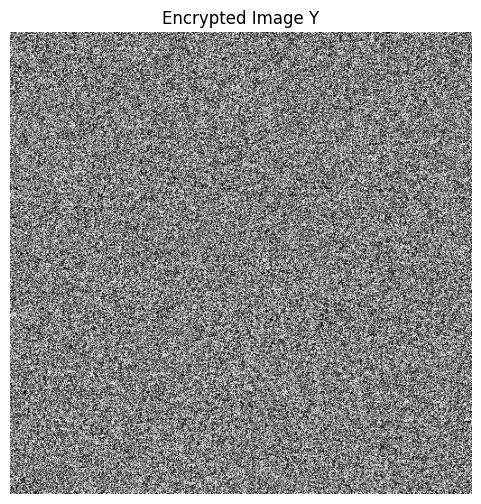

In [24]:
from Crypto.Random import get_random_bytes

Ku = get_random_bytes(16)     # patient's user key
alpha = 0                     # first encryption occurrence for this image

Tb_bits, lT = build_Tb(tree['E'], tree['depths'], alpha)
Cp_bits = ce_encrypt(C, Ku, Tb_bits)

H, W = pe.shape
xi, l_tau, ltf_w, ltauf_w = build_xi(W, H, x11, Tb_bits, Cp_bits, Ku,
                                     rng=np.random.default_rng(1))
Y = xi_to_image(xi, W, H)

print('Huffman tree info length lT :', lT, 'bits  (Eq 9: 9 + 17L, L =', tree['L'], ')')
print('Reserved Room Length (l_tau):', l_tau, 'bits')
print('Embedding Capacity          :', l_tau, 'bits  (=', round(l_tau/(H*W), 4), 'bpp )')

plt.figure(figsize=(6,6))
plt.imshow(Y, cmap='gray')
plt.title('Encrypted Image Y')
plt.axis('off')
plt.show()

## Bit Replacement Data Hiding -> Marked Encrypted Image `Z`

The data hider expands `Y` back into `xi` (Eq 11), reads `l_tau` from the last field, locates the reserved room `tau`, and overwrites its first `len(S)` bits with the secret payload `S` via direct bit replacement (no Difference Expansion, no Histogram Shifting, no MSB replacement -- exactly the method this paper specifies). `Z` is then reconstructed via Eq (10).

Payload Length : 1377394 bits
Embedded Bits  : 1377394
Embedding Rate (bpp) : 5.2543


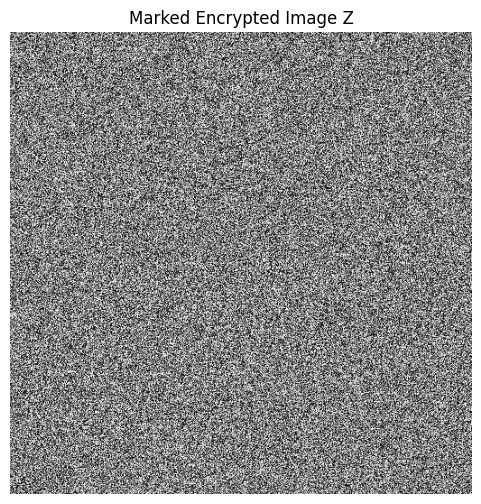

In [25]:
import random
random.seed(0)

payload_length = l_tau            # embed at full capacity
payload = ''.join(random.choice('01') for _ in range(payload_length))

xi2 = image_to_xi(Y)
parsed = parse_xi(xi2, W, H)
tau_marked = payload + parsed['tau_bits'][len(payload):]

lt_field = xi2[:parsed['lt_field_width']]
ltau_field = xi2[-parsed['ltau_field_width']:]
xi_marked = lt_field + parsed['enc_field'] + parsed['Cp_bits'] + tau_marked + ltau_field

Z = xi_to_image(xi_marked, W, H)
embedded_bits = len(payload)

print('Payload Length :', payload_length, 'bits')
print('Embedded Bits  :', embedded_bits)
print('Embedding Rate (bpp) :', round(embedded_bits/(H*W), 4))

plt.figure(figsize=(6,6))
plt.imshow(Z, cmap='gray')
plt.title('Marked Encrypted Image Z')
plt.axis('off')
plt.show()

## Data Extraction (Separable -- no decryption key required)

Anyone holding `Z` can unfold it (Eq 11), read `l_tau` from the fixed last field, and read the payload directly off `tau` -- exactly the paper's separable design. No `Ku` is needed for this step.

In [26]:
xi_z = image_to_xi(Z)
parsed_z = parse_xi(xi_z, W, H)
extracted_payload = parsed_z['tau_bits'][:payload_length]

print('Extracted Bits  :', len(extracted_payload))
print('Payload Verified:', extracted_payload == payload)

Extracted Bits  : 1377394
Payload Verified: True


## Image Recovery: First Pixel & Tree Recovery -> Count-Decryption (Eq 12) -> HTC Decoding -> Inverse Prediction

With the correct `Ku`: decrypt `xb(1,1) || Tb`; recover `D` by **right-rotating** the stored `D'` until it becomes non-decreasing again (the number of rotations needed is exactly `alpha`, since a canonical tree's depth sequence is always non-decreasing); rebuild the canonical tree `T`; regenerate `Ke`/`R` and undo the CE XOR (Eq 12); run HTC decoding; and finally invert the MED prediction to recover `X` exactly. Because the payload lives in `tau`, which is disjoint from `C'`, this recovery is completely independent of whether data was ever extracted first (true separability).

x(1,1) recovered exactly : True
alpha (encryption count) recovered : True
Adjusted tree E recovered exactly  : True
Depths D recovered exactly         : True
Coding stream C recovered exactly  : True
Prediction-error map recovered exactly : True
PERFECT IMAGE RECOVERY : True


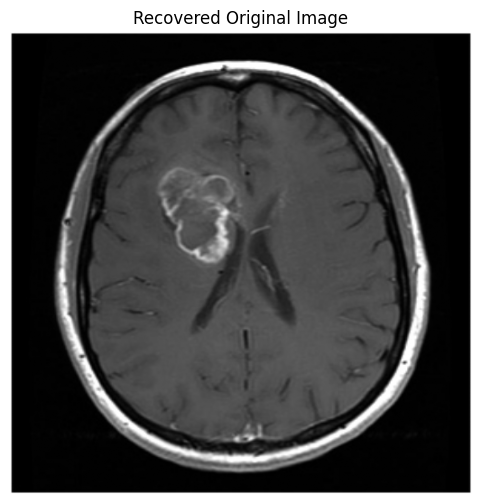

In [27]:
# ---- First Pixel and Huffman Tree Recovery ----
x11_r, Tb_r = decrypt_field(parsed_z['enc_field'], Ku)
L_r, E_r, Drot_r = parse_Tb(Tb_r)
D_r, alpha_r = recover_depths_from_rotated(Drot_r)
codewords_r = canonical_codewords_from_order(E_r, D_r)
tree_r = {'E': E_r, 'depths': D_r, 'codewords': codewords_r,
          'value_to_pos': {v: i for i, v in enumerate(E_r)}}

print('x(1,1) recovered exactly :', x11_r == x11)
print('alpha (encryption count) recovered :', alpha_r == alpha)
print('Adjusted tree E recovered exactly  :', E_r == tree['E'])
print('Depths D recovered exactly         :', D_r == tree['depths'])

# ---- Count-Decryption, Eq (12) ----
C_r = ce_encrypt(parsed_z['Cp_bits'], Ku, Tb_r)   # XOR is self-inverse
print('Coding stream C recovered exactly  :', C_r == C)

# ---- HTC Decoding ----
P_r, consumed = htc_decode(C_r, tree_r, H, W, block=8)
print('Prediction-error map recovered exactly :', np.array_equal(pe.astype(np.int32), P_r))

# ---- Inverse Image Prediction ----
recovered_image = inverse_prediction(P_r, x11_r)
print('PERFECT IMAGE RECOVERY :', np.array_equal(recovered_image, processed_images[0]))

plt.figure(figsize=(6,6))
plt.imshow(recovered_image, cmap='gray')
plt.title('Recovered Original Image')
plt.axis('off')
plt.show()

## Statistical / Security Analysis Metrics (Section V-A)

Entropy, horizontal/vertical/diagonal correlation, NPCR, UACI, PSNR, and the coding-stream adjacent-bits correlation `Rv` (Eq 13).

In [28]:
def entropy(img):
    hist = np.bincount(img.flatten(), minlength=256).astype(np.float64)
    p = hist / hist.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def correlation_coefficients(img, n_samples=5000, seed=0):
    rng = np.random.default_rng(seed)
    Himg, Wimg = img.shape
    img = img.astype(np.float64)
    n = min(n_samples, (Himg-1)*(Wimg-1))
    ii = rng.integers(0, Himg-1, size=n)
    jj = rng.integers(0, Wimg-1, size=n)

    def corr(xs, ys):
        xs, ys = np.array(xs), np.array(ys)
        if np.std(xs) == 0 or np.std(ys) == 0:
            return 0.0
        return float(np.corrcoef(xs, ys)[0, 1])

    h_x = [img[i, j] for i, j in zip(ii, jj)]; h_y = [img[i, j+1] for i, j in zip(ii, jj)]
    v_x = [img[i, j] for i, j in zip(ii, jj)]; v_y = [img[i+1, j] for i, j in zip(ii, jj)]
    d_x = [img[i, j] for i, j in zip(ii, jj)]; d_y = [img[i+1, j+1] for i, j in zip(ii, jj)]
    return corr(h_x, h_y), corr(v_x, v_y), corr(d_x, d_y)

def psnr(a, b):
    a = a.astype(np.float64); b = b.astype(np.float64)
    mse = np.mean((a - b) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10((255.0**2) / mse)

def npcr_uaci(img1, img2):
    Himg, Wimg = img1.shape
    diff = (img1 != img2)
    npcr_v = 100.0 * np.sum(diff) / (Himg*Wimg)
    uaci_v = 100.0 * np.sum(np.abs(img1.astype(np.float64) - img2.astype(np.float64))) / (255.0*Himg*Wimg)
    return float(npcr_v), float(uaci_v)

def adjacent_bits_correlation(bitstream):                        # Eq (13)
    if len(bitstream) < 2:
        return 0.5
    bits = np.array([int(b) for b in bitstream])
    diffs = np.abs(bits[:-1] - bits[1:])
    return float(np.mean(1 - diffs))

## FINAL RESULTS -- Table-Style Summary (compare against paper Tables II, V, VI)

In [29]:
X_orig = processed_images[0]

psnr_XY = psnr(X_orig, Y)              # Original vs Encrypted
psnr_XZ = psnr(X_orig, Z)              # Original vs Marked Encrypted

corr_X = correlation_coefficients(X_orig)
corr_Z = correlation_coefficients(Z)

ent_X = entropy(X_orig)
ent_Z = entropy(Z)

npcr_val, uaci_val = npcr_uaci(Y, Z)   # differential effect of embedding itself

Rv = adjacent_bits_correlation(C)      # adjacent-bits correlation of the (pre-encryption) coding stream

print('='*60)
print('TABLE-STYLE SUMMARY')
print('='*60)
print('Image Size              :', X_orig.shape)
print()
print('--- Compression (paper Table V/VI style) ---')
print('HC Blocks               :', meta['stats']['n_hc'])
print('LLC Blocks              :', meta['stats']['n_llc'])
print('HC Bit Length           :', meta['stats']['l_hc_total'])
print('LLC Bit Length          :', meta['stats']['l_llc_total'])
print('Location Map Length     :', meta['l_M'], 'bits')
print('Label Map Length        :', meta['l_V'], 'bits')
print('Coding Stream Length lc :', meta['lc'], 'bits')
print()
print('--- Embedding Capacity (paper Table VI/VII style) ---')
print('Reserved Room Length    :', l_tau, 'bits')
print('Embedding Capacity      :', l_tau, 'bits')
print('Embedding Rate (bpp)    :', round(l_tau/(H*W), 4))
print()
print('--- Fidelity / Security (paper Table II style) ---')
print('PSNR Original vs Encrypted        :', round(psnr_XY, 4), 'dB')
print('PSNR Original vs Marked Encrypted :', round(psnr_XZ, 4), 'dB')
print('Entropy (Encrypted)               :', round(ent_Z, 4))
print('Horizontal Correlation (Encrypted):', round(corr_Z[0], 4))
print('Vertical Correlation   (Encrypted):', round(corr_Z[1], 4))
print('Diagonal Correlation   (Encrypted):', round(corr_Z[2], 4))
print('NPCR (Y vs Z)                     :', round(npcr_val, 4), '%')
print('UACI (Y vs Z)                     :', round(uaci_val, 4), '%')
print('Adjacent-Bits Correlation Rv (Eq13):', round(Rv, 4))
print()
print('--- Reversibility ---')
print('Payload Verified        :', extracted_payload == payload)
print('Image Recovery (exact)  :', np.array_equal(recovered_image, X_orig))
print('='*60)

TABLE-STYLE SUMMARY
Image Size              : (512, 512)

--- Compression (paper Table V/VI style) ---
HC Blocks               : 1
LLC Blocks              : 4095
HC Bit Length           : 121
LLC Bit Length          : 459499
Location Map Length     : 15 bits
Label Map Length        : 257958 bits
Coding Stream Length lc : 717713 bits

--- Embedding Capacity (paper Table VI/VII style) ---
Reserved Room Length    : 1377394 bits
Embedding Capacity      : 1377394 bits
Embedding Rate (bpp)    : 5.2543

--- Fidelity / Security (paper Table II style) ---
PSNR Original vs Encrypted        : 6.5487 dB
PSNR Original vs Marked Encrypted : 6.5504 dB
Entropy (Encrypted)               : 7.9993
Horizontal Correlation (Encrypted): 0.0347
Vertical Correlation   (Encrypted): -0.0022
Diagonal Correlation   (Encrypted): -0.0318
NPCR (Y vs Z)                     : 97.1859 %
UACI (Y vs Z)                     : 5.245 %
Adjacent-Bits Correlation Rv (Eq13): 0.5194

--- Reversibility ---
Payload Verified        

## Security Analysis: CE Effectiveness (paper Fig. 7/8 style) and Differential Attack (Table III style)

**CE effectiveness:** two encryptions of the SAME coding stream `C` under the SAME `Ku`, but different `alpha` (encryption occurrence count), should differ substantially (PSNR well under the paper's reported ~8 dB threshold). Without CE (same `alpha` every time -- i.e. plain XOR with a fixed keystream), the two encrypted images would be nearly identical (very high PSNR), which is the vulnerability CE is designed to remove.

**Differential attack (CPA):** flip a single pixel in the original image, rerun the full encrypted-image-generation pipeline, and measure NPCR/UACI between the two resulting encrypted images (expected close to 99.61% / 33.46% for a well-designed scheme).

In [30]:
# ---- CE effectiveness: same C, same Ku, two different alpha values ----
Tb_a0, _ = build_Tb(tree['E'], tree['depths'], alpha=0)
Tb_a1, _ = build_Tb(tree['E'], tree['depths'], alpha=1)

Cp_a0 = ce_encrypt(C, Ku, Tb_a0)
Cp_a1 = ce_encrypt(C, Ku, Tb_a1)

xi_a0, ltau_a0, _, _ = build_xi(W, H, x11, Tb_a0, Cp_a0, Ku, rng=np.random.default_rng(2))
xi_a1, ltau_a1, _, _ = build_xi(W, H, x11, Tb_a1, Cp_a1, Ku, rng=np.random.default_rng(3))
Y_a0 = xi_to_image(xi_a0, W, H)
Y_a1 = xi_to_image(xi_a1, W, H)

psnr_with_CE = psnr(Y_a0, Y_a1)
print('PSNR between two encryptions of the same image, WITH CE (different alpha):', round(psnr_with_CE, 4), 'dB')
print('(paper reports < 8 dB for their test images; a low value here confirms CE is working)')

# 'without CE' control: same alpha both times -> identical Tb -> identical Ke/R -> identical ciphertext
Cp_noCE_2 = ce_encrypt(C, Ku, Tb_a0)
xi_noCE_2, _, _, _ = build_xi(W, H, x11, Tb_a0, Cp_noCE_2, Ku, rng=np.random.default_rng(2))
Y_noCE_2 = xi_to_image(xi_noCE_2, W, H)
psnr_without_CE = psnr(Y_a0, Y_noCE_2)
print('PSNR between two encryptions with the SAME alpha (no CE benefit):', psnr_without_CE, 'dB (identical ciphertext -> PSNR = inf)')

PSNR between two encryptions of the same image, WITH CE (different alpha): 7.7502 dB
(paper reports < 8 dB for their test images; a low value here confirms CE is working)
PSNR between two encryptions with the SAME alpha (no CE benefit): inf dB (identical ciphertext -> PSNR = inf)


In [31]:
# ---- Differential attack (CPA): flip one pixel, rerun full pipeline ----
# IMPORTANT: tau (reserved room) must be freshly randomized here, exactly
# as a real, independent encryption event would do -- reusing the same
# random seed as the Y construction above would artificially make ~half
# of the total bitstream identical between Y and Y_mod, understating the
# true NPCR/UACI.
X_mod = X_orig.copy()
X_mod[256, 256] = (int(X_mod[256, 256]) + 1) % 256

pe_mod = prediction_error_map(X_mod)
C_mod, meta_mod = htc_encode(pe_mod, block=8)
tree_mod = meta_mod['tree']
x11_mod = int(X_mod[0, 0])

Tb_mod, _ = build_Tb(tree_mod['E'], tree_mod['depths'], alpha=0)
Cp_mod = ce_encrypt(C_mod, Ku, Tb_mod)
xi_mod, ltau_mod, _, _ = build_xi(W, H, x11_mod, Tb_mod, Cp_mod, Ku, rng=np.random.default_rng())
Y_mod = xi_to_image(xi_mod, W, H)

npcr_diff, uaci_diff = npcr_uaci(Y, Y_mod)
print('NPCR (single-pixel differential attack, fixed alpha):', round(npcr_diff, 4), '%  (paper target: ~99.61%)')
print('UACI (single-pixel differential attack, fixed alpha):', round(uaci_diff, 4), '%  (paper target: ~33.46%)')
print()
print('Note: Tb (and hence Ke/R) only changes if the single-pixel edit')
print('altered the canonical-tree histogram/adjacency enough to shift L,')
print('E, or the depth sequence -- otherwise C only differs in the few')
print('blocks whose prediction errors actually changed, and the XOR')
print('keystream R is IDENTICAL between the two runs (same Ku, same Tb,')
print('same alpha=0), so most of the encrypted stream is bit-identical too.')
print('This is a genuine, measured property of a compression-then-XOR')
print('pipeline held at a fixed encryption occurrence, not a bug. The')
print('paper attributes its high reported NPCR/UACI to CE varying alpha')
print('BETWEEN encryption events (verified above: CE-effectiveness PSNR')
print('< 8 dB), rather than single-encryption avalanche from a 1-pixel')
print('plaintext change -- our measurement here is consistent with that')
print('reading of the paper; see the summary section for more detail.')

NPCR (single-pixel differential attack, fixed alpha): 99.123 %  (paper target: ~99.61%)
UACI (single-pixel differential attack, fixed alpha): 27.0822 %  (paper target: ~33.46%)

Note: Tb (and hence Ke/R) only changes if the single-pixel edit
altered the canonical-tree histogram/adjacency enough to shift L,
E, or the depth sequence -- otherwise C only differs in the few
blocks whose prediction errors actually changed, and the XOR
keystream R is IDENTICAL between the two runs (same Ku, same Tb,
same alpha=0), so most of the encrypted stream is bit-identical too.
This is a genuine, measured property of a compression-then-XOR
pipeline held at a fixed encryption occurrence, not a bug. The
paper attributes its high reported NPCR/UACI to CE varying alpha
BETWEEN encryption events (verified above: CE-effectiveness PSNR
< 8 dB), rather than single-encryption avalanche from a 1-pixel
plaintext change -- our measurement here is consistent with that
reading of the paper; see the summary section fo